In [78]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

In [79]:
class Option:
    def __init__(self, S, K, T, r, sigma, option_type):
        self.S = S              # prix spot
        self.K = K              # strike
        self.T = T              # maturité (en années)
        self.r = r              # taux
        self.sigma = sigma      # volatilité
        self.option_type = option_type  # "call" ou "put"

In [154]:
def d1(S, K, T, r, sigma):
    return (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))

def d2(S, K, T, r, sigma):
    return d1(S,K,T,r,sigma) - sigma*np.sqrt(T)

def delta(option):
    if option.option_type == "call":
        return norm.cdf(d1(option.S, option.K, option.T, option.r, option.sigma))
    else:
        return norm.cdf(d1(option.S, option.K, option.T, option.r, option.sigma)) - 1

def gamma(option):
    d1_val = d1(option.S, option.K, option.T, option.r, option.sigma)
    return norm.pdf(d1_val) / (option.S * option.sigma * np.sqrt(option.T))

def vega(option):
    d1_val = d1(option.S, option.K, option.T, option.r, option.sigma)
    return option.S * norm.pdf(d1_val) * np.sqrt(option.T)

def theta(option):
  d1_val = d1(option.S, option.K, option.T, option.r, option.sigma)
  d2_val = d2(option.S, option.K, option.T, option.r, option.sigma)
  if option.option_type=="call":
    return -option.S*norm.pdf(d1_val)*option.sigma/(2*np.sqrt(option.T))-option.r*option.K*np.exp(-option.r*option.T)*norm.cdf(-d2_val)
  else:
    return -option.S*norm.pdf(d1_val)*option.sigma/(2*np.sqrt(option.T))+option.r*option.K*np.exp(-option.r*option.T)*norm.cdf(d2_val)

def rho(option):
  d2_val = d2(option.S, option.K, option.T, option.r, option.sigma)
  if option.option_type=="call":
    return option.K*option.T*np.exp(-option.r*option.T)*norm.cdf(d2_val)
  else:
    return option.K*option.T*np.exp(-option.r*option.T)*norm.cdf(-d2_val)

def price(option):
  d1_val = d1(option.S, option.K, option.T, option.r, option.sigma)
  d2_val = d2(option.S, option.K, option.T, option.r, option.sigma)
  if option.option_type=="call":
    return option.S*norm.cdf(d1_val)-option.K*np.exp(-option.r*option.T)*norm.cdf(d2_val)
  else:
    return -option.S*norm.cdf(-d1_val)+option.K*np.exp(-option.r*option.T)*norm.cdf(-d2_val)



In [81]:
class Portfolio:
    def __init__(self):
        self.positions = []

    def add(self, instrument, quantity):
        self.positions.append((instrument, quantity))

    def total_delta(self):
        return sum(delta(inst) * qty for inst, qty in self.positions)

In [82]:
def total_greeks(self):
    totals = {
        "delta": 0,
        "gamma": 0,
        "vega": 0,
        "theta": 0,
        "rho": 0
    }

    for inst, qty in self.positions:
        totals["delta"] += delta(inst) * qty
        totals["gamma"] += gamma(inst) * qty
        totals["vega"] += vega(inst) * qty
        totals["theta"] += theta(inst) * qty
        totals["rho"] += rho(inst) * qty

    return totals

In [105]:
test=Portfolio()
test.add(Option(100, 100, 0.01, 0.05, 0.2, "put"), 1)
total_greeks(test)


{'delta': np.float64(-0.48603987043724173),
 'gamma': np.float64(0.19934900153612786),
 'vega': np.float64(3.986980030722558),
 'theta': np.float64(-37.34114540177004),
 'rho': np.float64(0.49376914388806264)}

Text(0.5, 1.0, 'put')

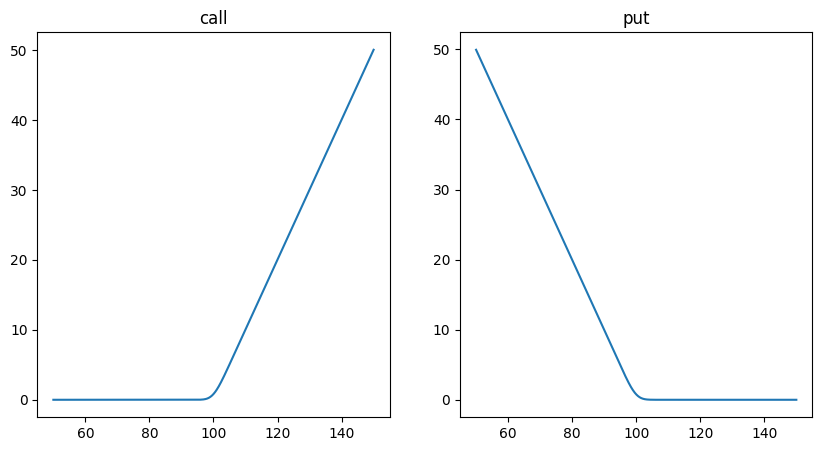

In [156]:
vect=np.linspace(50,150,1000)
call_fct=np.vectorize(lambda x: price(Option(x, 100, 0.01, 0.05, 0.2, "call")))
put_fct=np.vectorize(lambda x: price(Option(x, 100, 0.01, 0.05, 0.2, "put")))
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(10,5))
ax1.plot(vect,call_fct(vect))
ax1.set_title('call')
ax2.plot(vect,put_fct(vect),label='put')
ax2.set_title('put')
